In [39]:
import pandas as pd
import numpy as np

In [40]:
tbill_df = pd.read_parquet("../_data/CRSP_30_day_T_bill.parquet")
ret_df = pd.read_parquet("../_data/CRSP_monthly_stock.parquet")

In [41]:
tbill_df

,date,t30ret
0,1946-01-31,0.000291
1,1946-02-28,0.000272
2,1946-03-30,0.000288
3,1946-04-30,0.000309
4,1946-05-31,0.000291
...,...,...
739,2007-08-31,0.004205
740,2007-09-28,0.003347
741,2007-10-31,0.003212
742,2007-11-30,0.003395


In [42]:
ret_df

,date,vwretd,vwretx
0,1946-01-31,0.063402,0.062228
1,1946-02-28,-0.058257,-0.061743
2,1946-03-30,0.057941,0.054620
3,1946-04-30,0.042293,0.041154
4,1946-05-31,0.040195,0.036075
...,...,...,...
739,2007-08-31,0.011593,0.009641
740,2007-09-28,0.040822,0.039307
741,2007-10-31,0.025911,0.024770
742,2007-11-30,-0.049362,-0.051309


In [43]:
def replicate_table1(ret_df, tbill_df):
    ret = ret_df.copy()
    rf = tbill_df.copy()

    ret["date"] = pd.to_datetime(ret["date"])
    rf["date"] = pd.to_datetime(rf["date"])

    # Use month periods so 1946-03-30 vs 1946-03-31 does not matter
    ret["ym"] = ret["date"].dt.to_period("M")
    rf["ym"] = rf["date"].dt.to_period("M")

    df = (
        ret[["ym", "vwretd", "vwretx"]]
        .merge(rf[["ym", "t30ret"]], on="ym", how="inner")
        .sort_values("ym")
        .reset_index(drop=True)
    )

    # Paper sample
    df = df[(df["ym"] >= pd.Period("1946-01", "M")) &
            (df["ym"] <= pd.Period("2007-12", "M"))].copy()

    df["year"] = df["ym"].dt.year

    # Gross returns
    df["gross_mkt"] = 1.0 + df["vwretd"]   # reinvest in market
    df["gross_x"]   = 1.0 + df["vwretx"]   # ex-dividend price growth
    df["gross_rf"]  = 1.0 + df["t30ret"]   # reinvest in T-bill

    if (df[["gross_mkt", "gross_x", "gross_rf"]] <= 0).any().any():
        raise ValueError("Found gross return <= 0, cannot take logs / cumprod safely.")

    # Reconstruct an ex-dividend price index, normalized to 1 at the start
    # P_m = P_{m-1} * (1 + vwretx_m)
    df["P_ex_end"] = df["gross_x"].cumprod()
    df["P_ex_beg"] = df["P_ex_end"].shift(fill_value=1.0)

    # Monthly dividend paid during month m:
    # 1 + vwretd = (P_m + Div_m)/P_{m-1}
    # 1 + vwretx = P_m/P_{m-1}
    # => Div_m = P_{m-1} * (vwretd - vwretx)
    df["div_month"] = df["P_ex_beg"] * (df["vwretd"] - df["vwretx"])

    def future_prod_excluding_current(x):
        # Example: [g1, g2, g3] -> [g2*g3, g3, 1]
        return x.iloc[::-1].cumprod().iloc[::-1].shift(-1, fill_value=1.0)

    # Carry each month's dividend to the end of the same calendar year
    df["to_ye_rf"]  = df.groupby("year")["gross_rf"].transform(future_prod_excluding_current)
    df["to_ye_mkt"] = df.groupby("year")["gross_mkt"].transform(future_prod_excluding_current)

    # Contribution of each monthly dividend to year-end annual dividends
    df["cash_piece"]   = df["div_month"] * df["to_ye_rf"]
    df["market_piece"] = df["div_month"] * df["to_ye_mkt"]

    annual = (
        df.groupby("year", as_index=False)[["cash_piece", "market_piece"]]
          .sum()
          .rename(columns={"cash_piece": "D_cash", "market_piece": "D_market"})
    )

    # Annual log dividend growth
    annual["delta_d"]   = np.log(annual["D_cash"]   / annual["D_cash"].shift(1))
    annual["delta_d_M"] = np.log(annual["D_market"] / annual["D_market"].shift(1))

    growth = annual.dropna(subset=["delta_d", "delta_d_M"]).copy()

    table1 = pd.DataFrame({
        "Δd^M_t": growth["delta_d_M"].agg(["mean", "median", "std", "max", "min"]),
        "Δd_t":   growth["delta_d"].agg(["mean", "median", "std", "max", "min"]),
    })

    table1.index = ["Mean", "Median", "Standard deviation", "Maximum", "Minimum"]

    return df, annual, growth, table1

# run it
monthly, annual, growth, table1 = replicate_table1(ret_df, tbill_df)

print(table1.round(4))

                    Δd^M_t    Δd_t
Mean                0.0614  0.0606
Median              0.0534  0.0542
Standard deviation  0.1230  0.0626
Maximum             0.3697  0.2609
Minimum            -0.2884 -0.0544


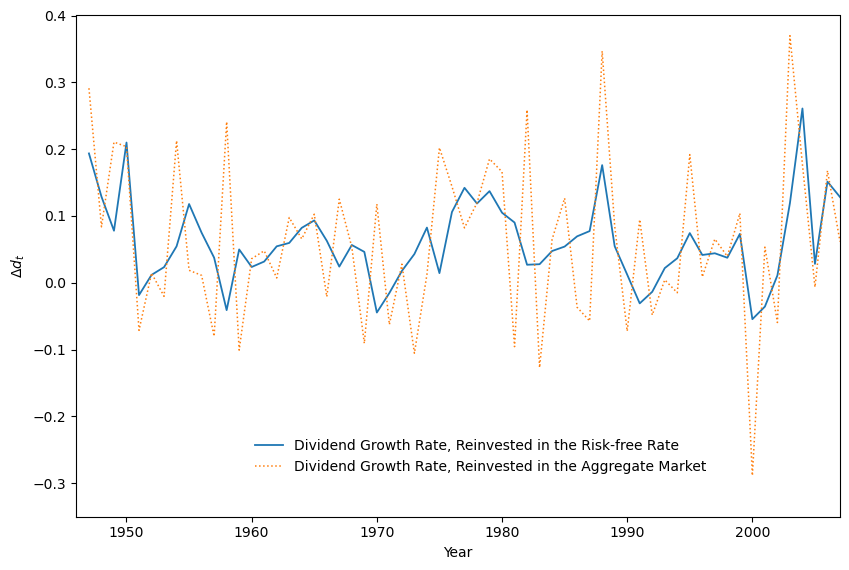

In [44]:
import matplotlib.pyplot as plt

# growth came from the earlier replicate_table1(...) code
# columns: year, delta_d, delta_d_M

fig1 = growth[["year", "delta_d", "delta_d_M"]].copy()
fig1 = fig1[(fig1["year"] >= 1947) & (fig1["year"] <= 2007)]

plt.figure(figsize=(8.6, 5.8))

# solid line: risk-free reinvestment
plt.plot(
    fig1["year"],
    fig1["delta_d"],
    linewidth=1.3,
    label="Dividend Growth Rate, Reinvested in the Risk-free Rate"
)

# dotted line: market reinvestment
plt.plot(
    fig1["year"],
    fig1["delta_d_M"],
    linestyle=":",
    linewidth=1.1,
    label="Dividend Growth Rate, Reinvested in the Aggregate Market"
)

plt.xlim(1946, 2007)
plt.ylim(-0.35, 0.40)
plt.xticks([1950, 1960, 1970, 1980, 1990, 2000])
plt.xlabel("Year")
plt.ylabel(r"$\Delta d_t$")

# place legend inside lower center, similar to the paper
plt.legend(
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.53, 0.06),
    fontsize=10
)

plt.tight_layout()
plt.show()

In [45]:
import statsmodels.api as sm

def _future_prod_excl_current(x):
    # [g1, g2, g3] -> [g2*g3, g3, 1]
    return x.iloc[::-1].cumprod().iloc[::-1].shift(-1, fill_value=1.0)
    #return x.iloc[::-1].cumprod().iloc[::-1]

def build_annual_series(ret_df, tbill_df):
    ret = ret_df.copy()
    rf = tbill_df.copy()

    ret["date"] = pd.to_datetime(ret["date"])
    rf["date"] = pd.to_datetime(rf["date"])

    # Use month periods so month-end day mismatches do not matter
    ret["ym"] = ret["date"].dt.to_period("M")
    rf["ym"] = rf["date"].dt.to_period("M")

    monthly = (
        ret[["ym", "vwretd", "vwretx"]]
        .merge(rf[["ym", "t30ret"]], on="ym", how="inner")
        .sort_values("ym")
        .reset_index(drop=True)
    )

    # Paper sample
    monthly = monthly[
        (monthly["ym"] >= pd.Period("1946-01", "M")) &
        (monthly["ym"] <= pd.Period("2007-12", "M"))
    ].copy()

    monthly["year"] = monthly["ym"].dt.year

    # Monthly gross returns
    monthly["gross_mkt"] = 1.0 + monthly["vwretd"]   # cum-dividend market return
    monthly["gross_x"]   = 1.0 + monthly["vwretx"]   # ex-dividend price return
    monthly["gross_rf"]  = 1.0 + monthly["t30ret"]   # 30-day T-bill return

    # Ex-dividend price index (arbitrary normalization)
    monthly["P_end"] = monthly["gross_x"].cumprod()
    monthly["P_beg"] = monthly["P_end"].shift(fill_value=1.0)

    # Monthly cash dividend paid during month m
    # 1+vwretd = (P_m + Div_m)/P_{m-1}
    # 1+vwretx = P_m/P_{m-1}
    # => Div_m = P_{m-1} * (vwretd - vwretx)
    monthly["div_month"] = monthly["P_beg"] * (monthly["vwretd"] - monthly["vwretx"])

    # Carry each month's dividend to year-end
    monthly["to_ye_rf"]  = monthly.groupby("year")["gross_rf"].transform(_future_prod_excl_current)
    monthly["to_ye_mkt"] = monthly.groupby("year")["gross_mkt"].transform(_future_prod_excl_current)

    monthly["div_cash_piece"]   = monthly["div_month"] * monthly["to_ye_rf"]
    monthly["div_market_piece"] = monthly["div_month"] * monthly["to_ye_mkt"]

    annual_div = (
        monthly.groupby("year", as_index=False)[["div_cash_piece", "div_market_piece"]]
        .sum()
        .rename(columns={
            "div_cash_piece": "D_cash",
            "div_market_piece": "D_market"
        })
    )

    # End-of-year ex-dividend price
    annual_price = (
        monthly.groupby("year", as_index=False)["P_end"]
        .last()
        .rename(columns={"P_end": "P"})
    )

    annual = annual_price.merge(annual_div, on="year", how="inner").sort_values("year").reset_index(drop=True)

    # Annual log dividend growth
    annual["delta_d"]   = np.log(annual["D_cash"]   / annual["D_cash"].shift(1))
    annual["delta_d_M"] = np.log(annual["D_market"] / annual["D_market"].shift(1))

    # Annual total log returns
    annual["r"]   = np.log((annual["P"] + annual["D_cash"])   / annual["P"].shift(1))
    annual["r_M"] = np.log((annual["P"] + annual["D_market"]) / annual["P"].shift(1))

    # Annual log price-dividend ratios
    annual["pd"]   = np.log(annual["P"] / annual["D_cash"])
    annual["pd_M"] = np.log(annual["P"] / annual["D_market"])

    return monthly, annual

def run_predictive_ols(annual, y_col, pd_col):
    reg = annual[["year", y_col, pd_col]].copy()
    reg["pd_lag"] = reg[pd_col].shift(1)

    # In paper notation: y_t on pd_{t-1}
    reg = reg.dropna(subset=[y_col, "pd_lag"]).copy()

    X = sm.add_constant(reg["pd_lag"])
    model = sm.OLS(reg[y_col], X).fit()

    out = {
        "n": int(model.nobs),
        "const": model.params["const"],
        "const_se": model.bse["const"],
        "beta": model.params["pd_lag"],
        "beta_se": model.bse["pd_lag"],
        "r2": model.rsquared,
        "adj_r2": model.rsquared_adj,
        "reg_df": reg,
        "model": model,
    }
    return out

def replicate_table3(ret_df, tbill_df):
    monthly, annual = build_annual_series(ret_df, tbill_df)

    res_rM = run_predictive_ols(annual, "r_M", "pd_M")
    res_r  = run_predictive_ols(annual, "r",   "pd")
    res_dM = run_predictive_ols(annual, "delta_d_M", "pd_M")
    res_d  = run_predictive_ols(annual, "delta_d",   "pd")

    table3 = pd.DataFrame({
        "r^M_t": [
            res_rM["const"], res_rM["const_se"],
            res_rM["beta"],  res_rM["beta_se"],
            res_rM["r2"],    res_rM["adj_r2"],
        ],
        "r_t": [
            res_r["const"], res_r["const_se"],
            res_r["beta"],  res_r["beta_se"],
            res_r["r2"],    res_r["adj_r2"],
        ],
        "Δd^M_t": [
            res_dM["const"], res_dM["const_se"],
            res_dM["beta"],  res_dM["beta_se"],
            res_dM["r2"],    res_dM["adj_r2"],
        ],
        "Δd_t": [
            res_d["const"], res_d["const_se"],
            res_d["beta"],  res_d["beta_se"],
            res_d["r2"],    res_d["adj_r2"],
        ],
    }, index=[
        "Constant",
        "SE(Constant)",
        "Lagged log PD coefficient",
        "SE(Lagged log PD)",
        "R2",
        "Adj. R2",
    ])

    return monthly, annual, table3, {
        "rM": res_rM["model"],
        "r":  res_r["model"],
        "dM": res_dM["model"],
        "d":  res_d["model"],
    }

# run
monthly, annual, table3, models = replicate_table3(ret_df, tbill_df)

print(table3.round(4))

# check
print("corr(r, r_M) =", annual[["r", "r_M"]].dropna().corr().iloc[0, 1].round(6))

                            r^M_t     r_t  Δd^M_t    Δd_t
Constant                   0.4733  0.4660  0.1949  0.1073
SE(Constant)               0.1536  0.1523  0.1268  0.0652
Lagged log PD coefficient -0.1070 -0.1042 -0.0392 -0.0136
SE(Lagged log PD)          0.0448  0.0440  0.0370  0.0188
R2                         0.0882  0.0868  0.0187  0.0088
Adj. R2                    0.0727  0.0713  0.0021 -0.0080
corr(r, r_M) = 0.99992


In [46]:
from statsmodels.tsa.arima.model import ARIMA

def _as_named_series(values, names):
    """
    Make params/bse robust across statsmodels versions.
    """
    if isinstance(values, pd.Series):
        return values.copy()
    return pd.Series(np.asarray(values), index=list(names), dtype=float)

def _as_named_cov(cov, names):
    """
    Make covariance matrix robust across statsmodels versions.
    """
    if isinstance(cov, pd.DataFrame):
        return cov.copy()
    arr = np.asarray(cov, dtype=float)
    return pd.DataFrame(arr, index=list(names), columns=list(names))

def replicate_table4(annual):
    """
    Expects annual to contain:
        year, delta_d_M, r
    where
        delta_d_M = market-reinvested annual log dividend growth
        r         = annual log return
    """

    reg = annual[["year", "delta_d_M", "r"]].copy()
    reg["dM_lag"] = reg["delta_d_M"].shift(1)
    reg["r_lag"] = reg["r"].shift(1)

    # Common sample for all 3 columns: usually 1948-2007, N=60
    reg = reg.dropna(subset=["delta_d_M", "dM_lag", "r_lag"]).reset_index(drop=True)

    # -------------------------
    # Column 1: AR(1) by OLS
    # Δd^M_t = a + b * Δd^M_{t-1} + e_t
    # -------------------------
    X1 = sm.add_constant(reg["dM_lag"])
    m1 = sm.OLS(reg["delta_d_M"], X1).fit()

    # -------------------------
    # Column 2: lagged return by OLS
    # Δd^M_t = a + b * r_{t-1} + e_t
    # -------------------------
    X2 = sm.add_constant(reg["r_lag"])
    m2 = sm.OLS(reg["delta_d_M"], X2).fit()

    # -------------------------
    # Column 3: ARMA(1,1) with lagged return
    # ARIMA here is "regression with ARMA errors"
    # -------------------------
    m3 = ARIMA(
        endog=reg["delta_d_M"],
        exog=reg[["r_lag"]],
        order=(1, 0, 1),
        trend="c",
        enforce_stationarity=True,
        enforce_invertibility=True,
    ).fit()

    # Robust param extraction
    param_names = getattr(m3, "param_names", None)
    if param_names is None:
        param_names = getattr(m3.model, "param_names", None)
    if param_names is None:
        raise RuntimeError("Could not recover parameter names from statsmodels result.")

    params = _as_named_series(m3.params, param_names)
    bse = _as_named_series(m3.bse, param_names)
    cov = _as_named_cov(m3.cov_params(), param_names)

    # Robustly find names across versions
    const_name = "const" if "const" in params.index else (
        "intercept" if "intercept" in params.index else None
    )
    if const_name is None:
        raise RuntimeError(f"Could not find constant term. Param names: {list(params.index)}")

    if "r_lag" in params.index:
        exog_name = "r_lag"
    else:
        excluded = {const_name, "ar.L1", "ma.L1", "sigma2"}
        exog_candidates = [n for n in params.index if n not in excluded]
        if len(exog_candidates) != 1:
            raise RuntimeError(f"Could not uniquely identify exogenous coefficient. Param names: {list(params.index)}")
        exog_name = exog_candidates[0]

    ar_name = "ar.L1"
    ma_name = "ma.L1"

    # Table IV says the reported constant in col 3 is the unconditional mean γ0
    # In this ARIMA regression-with-ARMA-errors form:
    #   y_t = const + beta * r_{t-1} + u_t
    # so unconditional mean of y_t is:
    #   gamma0 = const + beta * E[r_{t-1}]
    rbar = reg["r_lag"].mean()
    gamma0_hat = float(params[const_name] + params[exog_name] * rbar)

    # Delta-method SE for gamma0_hat
    gamma0_var = (
        cov.loc[const_name, const_name]
        + (rbar ** 2) * cov.loc[exog_name, exog_name]
        + 2 * rbar * cov.loc[const_name, exog_name]
    )
    gamma0_se = float(np.sqrt(gamma0_var))

    # Pseudo-R2 from fitted values
    fitted3 = pd.Series(np.asarray(m3.fittedvalues), index=reg.index)
    sse3 = float(((reg["delta_d_M"] - fitted3) ** 2).sum())
    sst3 = float(((reg["delta_d_M"] - reg["delta_d_M"].mean()) ** 2).sum())
    r2_3 = 1.0 - sse3 / sst3

    # Explanatory terms in col 3: AR(1), MA(1), r_{t-1}
    n = len(reg)
    k = 3
    adj_r2_3 = 1.0 - (1.0 - r2_3) * (n - 1) / (n - k - 1)

    table4 = pd.DataFrame({
        "(1) AR(1)": [
            m1.params["const"],
            m1.bse["const"],
            m1.params["dM_lag"],
            m1.bse["dM_lag"],
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            m1.rsquared,
            m1.rsquared_adj,
            len(reg),
        ],
        "(2) r_{t-1}": [
            m2.params["const"],
            m2.bse["const"],
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            m2.params["r_lag"],
            m2.bse["r_lag"],
            m2.rsquared,
            m2.rsquared_adj,
            len(reg),
        ],
        "(3) ARMA(1,1)+r_{t-1}": [
            gamma0_hat,
            gamma0_se,
            params[ar_name],
            bse[ar_name],
            params[ma_name],
            bse[ma_name],
            params[exog_name],
            bse[exog_name],
            r2_3,
            adj_r2_3,
            len(reg),
        ],
    }, index=[
        "Constant",
        "SE(Constant)",
        "AR(1)",
        "SE(AR(1))",
        "MA(1)",
        "SE(MA(1))",
        "r_{t-1}",
        "SE(r_{t-1})",
        "R2",
        "Adj. R2",
        "N",
    ])

    return reg, table4, {"col1": m1, "col2": m2, "col3": m3}

# run
reg4, table4, models4 = replicate_table4(annual)

print("sample years:", int(reg4["year"].min()), "to", int(reg4["year"].max()))
print(table4.round(4))

sample years: 1948 to 2007
              (1) AR(1)  (2) r_{t-1}  (3) ARMA(1,1)+r_{t-1}
Constant         0.0691       0.0957                 0.0574
SE(Constant)     0.0172       0.0172                 0.0146
AR(1)           -0.1880          NaN                -0.9267
SE(AR(1))        0.1250          NaN                 0.2171
MA(1)               NaN          NaN                 0.8884
SE(MA(1))           NaN          NaN                 0.2604
r_{t-1}             NaN      -0.3512                -0.3450
SE(r_{t-1})         NaN       0.0919                 0.1076
R2               0.0376       0.2012                 0.2097
Adj. R2          0.0210       0.1874                 0.1674
N               60.0000      60.0000                60.0000


In [47]:
from scipy.optimize import minimize
from statsmodels.tools.numdiff import approx_hess

def fit_armax11_conditional(y, y_lag, x):
    """
    Fit:
        y_t = c + phi*y_{t-1} + beta*x_t + e_t + theta*e_{t-1}
    by conditional Gaussian MLE with e_0 = 0.
    """

    y = np.asarray(y, dtype=float)
    y_lag = np.asarray(y_lag, dtype=float)
    x = np.asarray(x, dtype=float)

    T = len(y)
    if len(y_lag) != T or len(x) != T:
        raise ValueError("y, y_lag, and x must have the same length.")

    # OLS starting values
    X0 = np.column_stack([np.ones(T), y_lag, x])
    b0 = np.linalg.lstsq(X0, y, rcond=None)[0]
    c0, phi0, beta0 = b0[0], b0[1], b0[2]

    starts = [
        np.array([c0, np.clip(phi0, -0.8, 0.8), -0.3, beta0]),
        np.array([c0,  0.50, -0.50, beta0]),
        np.array([c0,  0.20, -0.20, beta0]),
        np.array([c0, -0.20,  0.20, beta0]),
        np.array([c0,  0.70, -0.70, beta0]),
    ]

    bounds = [
        (None, None),      # c
        (-0.999, 0.999),   # phi
        (-0.999, 0.999),   # theta
        (None, None),      # beta
    ]

    def innovations(params):
        c, phi, theta, beta = params
        e = np.zeros(T)
        for t in range(T):
            e_prev = e[t - 1] if t > 0 else 0.0
            e[t] = y[t] - c - phi * y_lag[t] - beta * x[t] - theta * e_prev
        return e

    def negloglike(params):
        c, phi, theta, beta = params

        if abs(phi) >= 0.999 or abs(theta) >= 0.999:
            return 1e12

        e = innovations(params)
        s2 = np.mean(e ** 2)
        if (not np.isfinite(s2)) or s2 <= 0:
            return 1e12

        return 0.5 * T * (np.log(2 * np.pi) + 1.0 + np.log(s2))

    best = None
    for s in starts:
        res = minimize(negloglike, s, method="L-BFGS-B", bounds=bounds)
        if res.success:
            if best is None or res.fun < best.fun:
                best = res
        elif best is None:
            best = res

    if best is None:
        raise RuntimeError("ARMAX optimization failed.")

    c_hat, phi_hat, theta_hat, beta_hat = best.x

    # Numerical Hessian for approximate covariance
    H = approx_hess(best.x, negloglike)
    try:
        cov = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(H)

    se = np.sqrt(np.maximum(np.diag(cov), 0.0))
    c_se, phi_se, theta_se, beta_se = se

    # Recursive fitted values
    fitted = np.zeros(T)
    ehat = np.zeros(T)
    for t in range(T):
        e_prev = ehat[t - 1] if t > 0 else 0.0
        fitted[t] = c_hat + phi_hat * y_lag[t] + beta_hat * x[t] + theta_hat * e_prev
        ehat[t] = y[t] - fitted[t]

    sse = float(np.sum((y - fitted) ** 2))
    sst = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - sse / sst

    k = 3  # AR(1), MA(1), lagged return
    adj_r2 = 1.0 - (1.0 - r2) * (T - 1) / (T - k - 1)

    # Table IV reports unconditional mean gamma0, not raw intercept c
    xbar = float(np.mean(x))
    gamma0_hat = (c_hat + beta_hat * xbar) / (1.0 - phi_hat)

    # Delta-method SE for gamma0
    grad = np.array([
        1.0 / (1.0 - phi_hat),                              # d/dc
        (c_hat + beta_hat * xbar) / (1.0 - phi_hat) ** 2,  # d/dphi
        0.0,                                                # d/dtheta
        xbar / (1.0 - phi_hat),                            # d/dbeta
    ])
    gamma0_var = float(grad @ cov @ grad)
    gamma0_se = np.sqrt(max(gamma0_var, 0.0))

    return {
        "c": c_hat,
        "c_se": c_se,
        "phi": phi_hat,
        "phi_se": phi_se,
        "theta": theta_hat,
        "theta_se": theta_se,
        "beta": beta_hat,
        "beta_se": beta_se,
        "gamma0": gamma0_hat,
        "gamma0_se": gamma0_se,
        "r2": r2,
        "adj_r2": adj_r2,
        "fitted": fitted,
        "resid": y - fitted,
        "success": bool(best.success),
        "message": best.message,
    }


def replicate_table4_fixed(annual):
    """
    Expects annual to contain:
        year, delta_d_M, r
    """

    reg = annual[["year", "delta_d_M", "r"]].copy()
    reg["dM_lag"] = reg["delta_d_M"].shift(1)
    reg["r_lag"] = reg["r"].shift(1)

    # Common sample for all columns
    reg = reg.dropna(subset=["delta_d_M", "dM_lag", "r_lag"]).reset_index(drop=True)

    # Column 1: OLS AR(1)
    X1 = sm.add_constant(reg["dM_lag"])
    m1 = sm.OLS(reg["delta_d_M"], X1).fit()

    # Column 2: OLS on lagged return
    X2 = sm.add_constant(reg["r_lag"])
    m2 = sm.OLS(reg["delta_d_M"], X2).fit()

    # Column 3: direct ARMAX(1,1) with lagged return
    m3 = fit_armax11_conditional(
        y=reg["delta_d_M"].values,
        y_lag=reg["dM_lag"].values,
        x=reg["r_lag"].values,
    )

    table4 = pd.DataFrame({
        "(1) AR(1)": [
            m1.params["const"],
            m1.bse["const"],
            m1.params["dM_lag"],
            m1.bse["dM_lag"],
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            m1.rsquared,
            m1.rsquared_adj,
        ],
        "(2) r_{t-1}": [
            m2.params["const"],
            m2.bse["const"],
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            m2.params["r_lag"],
            m2.bse["r_lag"],
            m2.rsquared,
            m2.rsquared_adj,
        ],
        "(3) ARMAX(1,1)+r_{t-1}": [
            m3["gamma0"],      # reported constant in the paper
            m3["gamma0_se"],
            m3["phi"],
            m3["phi_se"],
            m3["theta"],
            m3["theta_se"],
            m3["beta"],
            m3["beta_se"],
            m3["r2"],
            m3["adj_r2"],
        ],
    }, index=[
        "Constant",
        "SE(Constant)",
        "AR(1)",
        "SE(AR(1))",
        "MA(1)",
        "SE(MA(1))",
        "r_{t-1}",
        "SE(r_{t-1})",
        "R2",
        "Adj. R2",
    ])

    return reg, table4, {"col1": m1, "col2": m2, "col3": m3}


# Run it
reg4, table4, models4 = replicate_table4_fixed(annual)

print(table4.round(4))

              (1) AR(1)  (2) r_{t-1}  (3) ARMAX(1,1)+r_{t-1}
Constant         0.0691       0.0957                  0.0530
SE(Constant)     0.0172       0.0172                  0.0112
AR(1)           -0.1880          NaN                  0.5641
SE(AR(1))        0.1250          NaN                  0.1438
MA(1)               NaN          NaN                 -0.6438
SE(MA(1))           NaN          NaN                  0.2114
r_{t-1}             NaN      -0.3512                 -0.3184
SE(r_{t-1})         NaN       0.0919                  0.1157
R2               0.0376       0.2012                  0.2747
Adj. R2          0.0210       0.1874                  0.2358
